# 📊 EDA – DocLayout-YOLO × layout_data

**Model**: DocLayout-YOLOv10m (640px)  
**Dataset**: `models/doclayout-yolo/layout_data` — **bộ data lớn hơn, 3 classes**  
**Mục tiêu**: Phân tích dataset layout_data và kết quả training trên 3 class: `table`, `photo`, `text`

| | DocLayout-YOLO × layout_data |
|---|---|
| **Dataset** | layout_data (3038 train / 382 val) |
| **Classes** | 3: `table`, `photo`, `text` |
| **Model** | DocLayout-YOLOv10m (pretrained DocStructBench) |
| **Epochs** | 100 (val mỗi 5 epoch) |
| **Optimizer** | SGD, lr0=0.01 |

---
**Sections:**
1. Dataset Overview – layout_data (3 classes, phân bố bbox)
2. Class Distribution & Imbalance Analysis
3. Training Curves – Loss & Metrics
4. Val Evaluation Results (confusion matrix, PR/F1 curves)
5. Per-class Performance
6. Kết luận

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from pathlib import Path
from PIL import Image

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13})

ROOT       = Path('..')
DOC_ROOT   = ROOT / 'models/doclayout-yolo'
DATASET    = DOC_ROOT / 'layout_data'
TRAIN_DIR  = DOC_ROOT / 'doclayout-yolo_640 finetune in layout data'
VAL_DIR    = TRAIN_DIR / 'val_results'
RESULTS_CSV = VAL_DIR / 'results.csv'
EVAL_XLSX  = VAL_DIR / 'eval_results.xlsx'

CLASS_NAMES = {0: 'table', 1: 'photo', 2: 'text'}
CLASS_COLORS = {
    'table': '#e74c3c',
    'photo': '#2980b9',
    'text':  '#27ae60',
}

print('✅ Setup OK')
print(f'   Dataset:  {DATASET.resolve()}')
print(f'   CSV:      {RESULTS_CSV.exists()}')
print(f'   XLSX:     {EVAL_XLSX.exists()}')
print(f'   Val imgs: {len(list((VAL_DIR).glob("*.jpg")))} files')

✅ Setup OK
   Dataset:  /home/hoai/user/resource/fipilot/backend/models/doclayout-yolo/layout_data
   CSV:      True
   XLSX:     True
   Val imgs: 6 files


---
## 1. Dataset Overview – layout_data

In [2]:
def read_labels(lbl_dir):
    lbl_dir = Path(lbl_dir)
    if not lbl_dir.exists():
        return pd.DataFrame(columns=['cls','cx','cy','w','h','img']), []
    records, per_img = [], []
    for f in sorted(lbl_dir.glob('*.txt')):
        lines = [l.strip() for l in f.read_text().splitlines() if l.strip()]
        per_img.append(len(lines))
        for l in lines:
            p = list(map(float, l.split()))
            records.append({'cls':int(p[0]),'cx':p[1],'cy':p[2],'w':p[3],'h':p[4],'img':f.stem})
    if not records:
        return pd.DataFrame(columns=['cls','cx','cy','w','h','img']), per_img
    return pd.DataFrame(records), per_img

splits = {}
for split in ['train', 'val']:
    df, ppi = read_labels(DATASET / 'labels' / split)
    img_files = list((DATASET / 'images' / split).glob('*'))
    df['class_name'] = df['cls'].map(CLASS_NAMES)
    df['ar'] = df['w'] / df['h'].replace(0, np.nan)
    df['area'] = df['w'] * df['h']
    splits[split] = {'df': df, 'ppi': ppi, 'n_imgs': len(img_files)}

df_all = pd.concat([splits[s]['df'] for s in splits], ignore_index=True)

print('=== layout_data Stats ===')
for split, data in splits.items():
    df, ppi = data['df'], data['ppi']
    print(f'  [{split}] {data["n_imgs"]} imgs | {len(df)} bbox | avg {np.mean(ppi):.1f}/img | max {max(ppi)}/img')

print(f'  [total] {sum(d["n_imgs"] for d in splits.values())} imgs | {len(df_all)} bbox')
print()
print('Class counts (train+val):')
cls_count = df_all['class_name'].value_counts()
for cls, cnt in cls_count.items():
    pct = 100 * cnt / len(df_all)
    print(f'  {cls:<8}: {cnt:6d} ({pct:.1f}%)')

=== layout_data Stats ===
  [train] 3038 imgs | 77384 bbox | avg 25.5/img | max 96/img
  [val] 382 imgs | 9624 bbox | avg 25.2/img | max 67/img
  [total] 3420 imgs | 87008 bbox

Class counts (train+val):
  text    :  83538 (96.0%)
  photo   :   2143 (2.5%)
  table   :   1327 (1.5%)


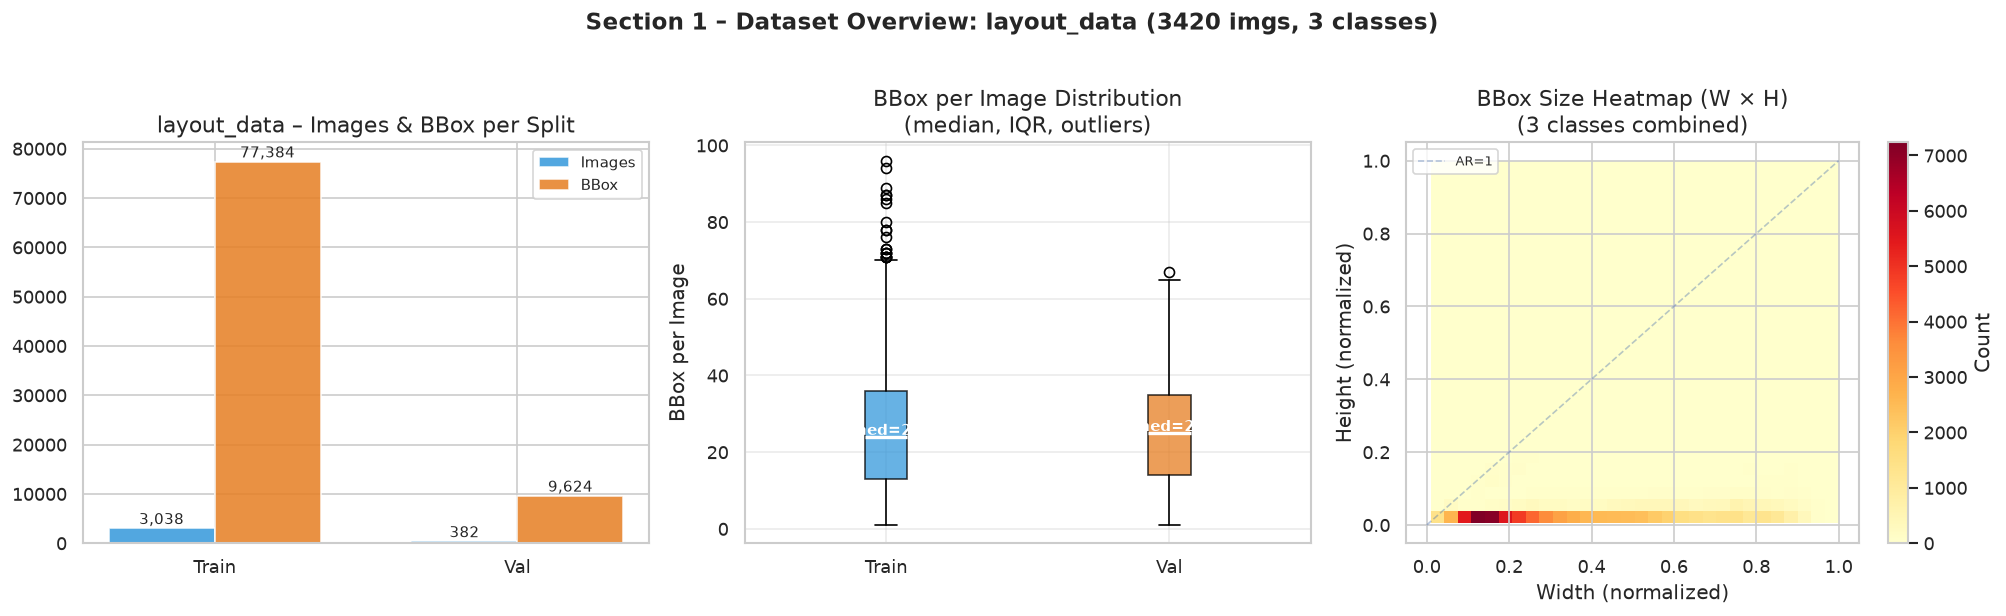

Saved: eda_layout_s1_overview.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1.1: Images & bbox count per split
ax = axes[0]
split_names = ['train', 'val']
x = np.arange(2); w = 0.35
b1 = ax.bar(x-w/2, [splits[s]['n_imgs'] for s in split_names], w,
            label='Images', color='#3498db', alpha=0.85)
b2 = ax.bar(x+w/2, [len(splits[s]['df']) for s in split_names], w,
            label='BBox', color='#e67e22', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Train', 'Val'])
ax.set_title('layout_data – Images & BBox per Split')
ax.legend(fontsize=9)
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# 1.2: BBox/img distribution (violin)
ax = axes[1]
ppi_data = {s: splits[s]['ppi'] for s in split_names}
bplot = ax.boxplot(
    [ppi_data[s] for s in split_names],
    tick_labels=['Train', 'Val'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bplot['boxes'], ['#3498db','#e67e22']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_ylabel('BBox per Image')
ax.set_title('BBox per Image Distribution\n(median, IQR, outliers)')
for i, s in enumerate(split_names, 1):
    ax.text(i, np.median(ppi_data[s])+0.5, f'med={np.median(ppi_data[s]):.0f}',
            ha='center', fontsize=9, color='white', fontweight='bold')
ax.grid(alpha=0.4)

# 1.3: BBox size heatmap (w vs h)
ax = axes[2]
h2d, xedges, yedges = np.histogram2d(
    df_all['w'].clip(0,1), df_all['h'].clip(0,1), bins=30
)
im = ax.imshow(h2d.T, origin='lower', aspect='auto',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Count')
ax.set_xlabel('Width (normalized)'); ax.set_ylabel('Height (normalized)')
ax.set_title('BBox Size Heatmap (W × H)\n(3 classes combined)')
ax.plot([0,1],[0,1],'b--',alpha=0.4,lw=1,label='AR=1')
ax.legend(fontsize=8)

plt.suptitle('Section 1 – Dataset Overview: layout_data (3420 imgs, 3 classes)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_layout_s1_overview.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_layout_s1_overview.png')

---
## 2. Class Distribution & Imbalance

TypeError: Axes.pie() got an unexpected keyword argument 'tick_labels'

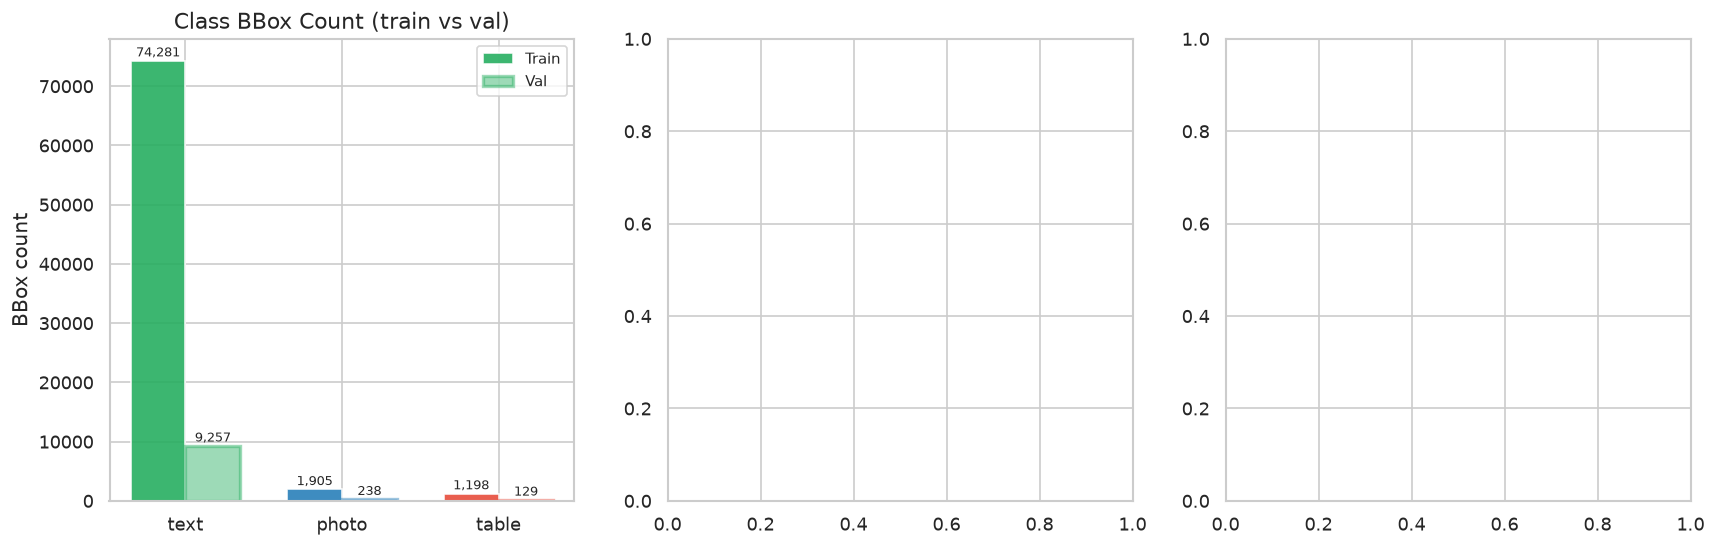

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 2.1: Class count bar
ax = axes[0]
cls_order = ['text', 'photo', 'table']
cls_counts_train = splits['train']['df']['class_name'].value_counts()
cls_counts_val   = splits['val']['df']['class_name'].value_counts()
x = np.arange(3); w = 0.35
cols = [CLASS_COLORS[c] for c in cls_order]
b1 = ax.bar(x-w/2, [cls_counts_train.get(c,0) for c in cls_order], w,
            label='Train', color=cols, alpha=0.9)
b2 = ax.bar(x+w/2, [cls_counts_val.get(c,0) for c in cls_order], w,
            label='Val',   color=cols, alpha=0.45, edgecolor=cols, lw=2)
ax.set_xticks(x); ax.set_xticklabels(cls_order)
ax.set_ylabel('BBox count'); ax.legend(fontsize=9)
ax.set_title('Class BBox Count (train vs val)')
for bar in [*b1, *b2]:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# 2.2: Class imbalance pie
ax = axes[1]
cls_all_counts = df_all['class_name'].value_counts()
wedge_colors = [CLASS_COLORS[c] for c in cls_all_counts.index]
wedges, texts, autotexts = ax.pie(
    cls_all_counts.values,
    tick_labels=[f"{c}\n({v:,})" for c, v in zip(cls_all_counts.index, cls_all_counts.values)],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title(f'Class Imbalance (total {len(df_all):,} bbox)\n⚠️ text 96% >> table 1.5%')

# 2.3: BBox size per class (box plot)
ax = axes[2]
class_areas = [df_all[df_all['class_name']==c]['area'].clip(0,0.5).tolist() for c in cls_order]
bplot = ax.boxplot(class_areas, tick_labels=cls_order, patch_artist=True,
                   medianprops=dict(color='white', linewidth=2))
for patch, cls in zip(bplot['boxes'], cls_order):
    patch.set_facecolor(CLASS_COLORS[cls]); patch.set_alpha(0.8)
ax.set_ylabel('BBox Area (w×h, clipped @0.5)')
ax.set_title('BBox Size per Class\n(normalized area)')
for i, (c, cls) in enumerate(zip(class_areas, cls_order), 1):
    med = np.median(c)
    ax.text(i, med+0.005, f'{med:.3f}', ha='center', fontsize=9,
            color='white', fontweight='bold')
ax.grid(alpha=0.4)

plt.suptitle('Section 2 – Class Distribution & Imbalance: layout_data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_layout_s2_class.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_layout_s2_class.png')
print()
print(f'⚠️  Class Imbalance ratio: text/table = {cls_counts_train.get("text",0)/max(cls_counts_train.get("table",1),1):.0f}:1')

In [ ]:
# BBox spatial heatmap per class (centre distribution)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, cls in zip(axes, cls_order):
    sub = df_all[df_all['class_name']==cls]
    h2d, xe, ye = np.histogram2d(sub['cx'].clip(0,1), sub['cy'].clip(0,1), bins=25)
    im = ax.imshow(h2d.T, origin='lower', aspect='auto',
                   extent=[0,1,0,1], cmap='hot_r')
    plt.colorbar(im, ax=ax, label='Count')
    ax.set_xlabel('Center X'); ax.set_ylabel('Center Y')
    n = len(sub)
    ax.set_title(f'BBox Centre Heatmap – "{cls}"\n({n:,} bbox)',
                 color=CLASS_COLORS[cls], fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Section 2b – Spatial Distribution of BBox Centres per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_layout_s2b_spatial.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_layout_s2b_spatial.png')

---
## 3. Training Curves

In [ ]:
csv = pd.read_csv(RESULTS_CSV)
csv.columns = csv.columns.str.strip()

c50 = 'metrics/mAP50(B)'
c95 = 'metrics/mAP50-95(B)'
pc  = 'metrics/precision(B)'
rc  = 'metrics/recall(B)'

valid_csv = csv[csv[c50] > 0].copy()
best_idx  = valid_csv[c50].idxmax()
best_ep   = valid_csv.loc[best_idx, 'epoch']

print(f'Total epochs: {len(csv)}')
print(f'Best mAP50: {valid_csv.loc[best_idx, c50]:.4f} @ epoch {int(best_ep)}')
print(f'Best mAP50-95: {valid_csv.loc[valid_csv[c95].idxmax(), c95]:.4f} @ epoch {int(valid_csv.loc[valid_csv[c95].idxmax(),"epoch"])}')
print(f'Early stopping: patience=30')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

TEAL  = '#16a085'
PURPLE = '#8e44ad'
RED   = '#e74c3c'
BLUE  = '#2980b9'

# ── 3.1: mAP50 ─────────────────────────────────────────────────────────
ax = axes[0,0]
ax.plot(valid_csv['epoch'], valid_csv[c50], color=TEAL, lw=2.5, label='mAP50')
bi = valid_csv[c50].idxmax()
ax.scatter(valid_csv.loc[bi,'epoch'], valid_csv.loc[bi,c50], s=150, color=RED, zorder=5)
ax.annotate(f"Best: {valid_csv.loc[bi,c50]:.4f}\n@ep{int(valid_csv.loc[bi,'epoch'])}",
            xy=(valid_csv.loc[bi,'epoch'], valid_csv.loc[bi,c50]),
            xytext=(10,5), textcoords='offset points', fontsize=9,
            color=RED, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP50')
ax.set_title('mAP50 theo Epoch (VAL, mỗi 5 epoch)'); ax.grid(alpha=0.4)
ax.set_ylim(0,1)

# ── 3.2: mAP50-95 ──────────────────────────────────────────────────────
ax = axes[0,1]
ax.plot(valid_csv['epoch'], valid_csv[c95], color=PURPLE, lw=2.5, label='mAP50-95')
bi95 = valid_csv[c95].idxmax()
ax.scatter(valid_csv.loc[bi95,'epoch'], valid_csv.loc[bi95,c95], s=150, color=RED, zorder=5)
ax.annotate(f"Best: {valid_csv.loc[bi95,c95]:.4f}\n@ep{int(valid_csv.loc[bi95,'epoch'])}",
            xy=(valid_csv.loc[bi95,'epoch'], valid_csv.loc[bi95,c95]),
            xytext=(10,5), textcoords='offset points', fontsize=9,
            color=RED, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP50-95')
ax.set_title('mAP50-95 theo Epoch (VAL)\n(bbox localization tighter IoU)'); ax.grid(alpha=0.4)
ax.set_ylim(0,1)

# ── 3.3: Precision & Recall ─────────────────────────────────────────────
ax = axes[0,2]
ax.plot(valid_csv['epoch'], valid_csv[pc], color='#e67e22', lw=2, label='Precision')
ax.plot(valid_csv['epoch'], valid_csv[rc], color='#3498db', lw=2, label='Recall')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
ax.set_title('Precision & Recall theo Epoch (VAL)'); ax.legend(fontsize=9); ax.grid(alpha=0.4)
ax.set_ylim(0,1)

# ── 3.4: Train Box Loss (om vs oo) ─────────────────────────────────────
ax = axes[1,0]
ax.plot(csv['epoch'], csv['train/box_om'], color=BLUE, lw=2, label='box_om (obj miss)')
ax.plot(csv['epoch'], csv['train/box_oo'], color=RED, lw=2, label='box_oo (obj over)', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Train Box Loss (om=object-missing, oo=object-overlap)'); ax.legend(fontsize=9); ax.grid(alpha=0.4)

# ── 3.5: Train Cls Loss ──────────────────────────────────────────────────
ax = axes[1,1]
ax.plot(csv['epoch'], csv['train/cls_om'], color=BLUE, lw=2, label='cls_om')
ax.plot(csv['epoch'], csv['train/cls_oo'], color=RED, lw=2, label='cls_oo', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Train Class Loss'); ax.legend(fontsize=9); ax.grid(alpha=0.4)

# ── 3.6: Val Loss ────────────────────────────────────────────────────────
ax = axes[1,2]
valid_loss = csv[csv['val/box_om'] > 0]
if not valid_loss.empty:
    ax.plot(valid_loss['epoch'], valid_loss['val/box_om'], color=BLUE, lw=2, label='val/box_om')
    ax.plot(valid_loss['epoch'], valid_loss['val/cls_om'], color=RED, lw=2, label='val/cls_om', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Val Loss (box & cls)'); ax.legend(fontsize=9); ax.grid(alpha=0.4)

plt.suptitle('Section 3 – DocLayout-YOLO Training Curves on layout_data (100 epochs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_layout_s3_training.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_layout_s3_training.png')

---
## 4. Val Evaluation – Confusion Matrix & Curves

In [ ]:
# 4.1: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in [
    (axes[0], 'confusion_matrix.png', 'Confusion Matrix (Raw counts)'),
    (axes[1], 'confusion_matrix_normalized.png', 'Confusion Matrix (Normalized)'),
]:
    img = Image.open(VAL_DIR / fname)
    ax.imshow(img); ax.axis('off'); ax.set_title(title, fontsize=11)

plt.suptitle('Section 4 – DocLayout-YOLO: Confusion Matrix on layout_data val set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_layout_s4_confusion.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: eda_layout_s4_confusion.png')

In [ ]:
# 4.2: Performance curves (PR, F1, P, R)
curve_files = [
    ('PR_curve.png',  'PR Curve'),
    ('F1_curve.png',  'F1 Curve'),
    ('P_curve.png',   'Precision Curve'),
    ('R_curve.png',   'Recall Curve'),
]
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (fname, title) in zip(axes, curve_files):
    p = VAL_DIR / fname
    if p.exists():
        ax.imshow(Image.open(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5,0.5,'Not found',ha='center',transform=ax.transAxes); ax.axis('off')

plt.suptitle('Section 4b – DocLayout-YOLO: Performance Curves on layout_data val set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_layout_s4_curves.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: eda_layout_s4_curves.png')

In [ ]:
# 4.3: Val batch predictions
pred_files = sorted([f for f in VAL_DIR.glob('val_batch*_pred.jpg')])[:3]
lbl_files  = sorted([f for f in VAL_DIR.glob('val_batch*_labels.jpg')])[:3]
n = len(pred_files)

if n > 0:
    fig, axes = plt.subplots(2, n, figsize=(8*n, 11))
    if n == 1: axes = axes.reshape(2,1)
    for i, (pf, lf) in enumerate(zip(pred_files, lbl_files)):
        axes[0,i].imshow(Image.open(lf));  axes[0,i].axis('off')
        axes[0,i].set_title(f'Ground Truth – Batch {i}', fontsize=9, fontweight='bold')
        axes[1,i].imshow(Image.open(pf));  axes[1,i].axis('off')
        axes[1,i].set_title(f'Prediction – Batch {i}', fontsize=9, fontweight='bold')
    plt.suptitle('DocLayout-YOLO: Val Batch Predictions vs Ground Truth',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_layout_s4_predictions.png', bbox_inches='tight', dpi=100)
    plt.show()
    print('Saved: eda_layout_s4_predictions.png')

---
## 5. Per-class Performance

In [ ]:
xl = pd.ExcelFile(EVAL_XLSX)
overall_df   = xl.parse('Overall')
per_class_df = xl.parse('Per-Class')

print('=== Overall VAL Metrics ===')
print(overall_df.to_string(index=False))
print()
print('=== Per-Class VAL Metrics ===')
print(per_class_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 5.1: Per-class bar comparison
ax = axes[0]
metrics_plot = ['precision', 'recall', 'f1', 'mAP50-95']
metric_labels = ['Precision', 'Recall', 'F1', 'mAP50-95']
x = np.arange(len(metrics_plot)); w = 0.22

for i, cls in enumerate(per_class_df['class']):
    vals = [per_class_df.loc[i, m] for m in metrics_plot]
    offset = (i - len(per_class_df)/2 + 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=cls,
                  color=CLASS_COLORS.get(cls, '#95a5a6'), alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08); ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics (VAL set)\n3 classes: table / photo / text')
ax.legend(fontsize=10)

# 5.2: Radar chart
ax2 = axes[1]
ax2.axis('off')

# Draw manual radar
from matplotlib.patches import FancyBboxPatch
categories = metric_labels
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = fig.add_subplot(1, 2, 2, polar=True)
ax2.set_visible(False)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=10)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax_radar.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax_radar.grid(alpha=0.4)

for _, row in per_class_df.iterrows():
    cls = row['class']
    vals = [row[m] for m in metrics_plot] + [row[metrics_plot[0]]]
    color = CLASS_COLORS.get(cls, '#95a5a6')
    ax_radar.plot(angles, vals, color=color, lw=2, label=cls)
    ax_radar.fill(angles, vals, color=color, alpha=0.1)

ax_radar.set_title('Per-Class Radar Chart', fontsize=11, fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.suptitle('Section 5 – Per-Class Performance: table / photo / text',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_layout_s5_perclass.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_layout_s5_perclass.png')

---
## 6. Kết luận

In [ ]:
print('=' * 65)
print('KẾT LUẬN – DocLayout-YOLO × layout_data')
print('=' * 65)
print()
print('1. DATASET: layout_data')
print(f'   • {splits["train"]["n_imgs"]:,} train + {splits["val"]["n_imgs"]:,} val = {splits["train"]["n_imgs"]+splits["val"]["n_imgs"]:,} images')
print(f'   • 3 classes: table, photo, text')
print(f'   • Avg {np.mean(splits["train"]["ppi"]):.1f} bbox/img (train), {np.mean(splits["val"]["ppi"]):.1f} bbox/img (val)')
print(f'   • ⚠️  Class imbalance: text ({int(cls_counts_train.get("text",0)):,}) >> photo ({int(cls_counts_train.get("photo",0)):,}) >> table ({int(cls_counts_train.get("table",0)):,})')
print(f'   • text/table ratio: {cls_counts_train.get("text",0)/max(cls_counts_train.get("table",1),1):.0f}:1 (cực kỳ mất cân bằng)')
print()
print('2. TRAINING (100 epochs, patience=30, val mỗi 5 ep)')
print(f'   • Best mAP50:    {valid_csv.loc[valid_csv[c50].idxmax(), c50]:.4f} @ ep{int(valid_csv.loc[valid_csv[c50].idxmax(), "epoch"])}')
print(f'   • Best mAP50-95: {valid_csv.loc[valid_csv[c95].idxmax(), c95]:.4f} @ ep{int(valid_csv.loc[valid_csv[c95].idxmax(), "epoch"])}')
print(f'   • Model chạy hết 100 epochs (không early stop)')
print()
print('3. PER-CLASS (VAL set)')
for _, row in per_class_df.iterrows():
    print(f'   • {row["class"]:<6}: P={row["precision"]:.3f}, R={row["recall"]:.3f}, F1={row["f1"]:.3f}, mAP50-95={row["mAP50-95"]:.3f}')
print()
print('4. OVERALL (eval_results.xlsx)') 
for _, row in overall_df.iterrows():
    print(f'   • {row["Metric"]:<12}: {row["Value"]:.4f}')
print()
print('5. NHẬN XÉT')
print('   • text mạnh nhất (P=0.90, R=0.90) do chiếm 96% data')
print('   • photo thấp nhất (F1=0.743) — ít data + visual khó distinguish')
print('   • table ở giữa (F1=0.814) — mặc dù ít data nhưng visual rõ ràng')
print('   • Imbalance nghiêm trọng: cân nhắc class weighting hoặc oversampling')
print()
print('6. RECOMMENDATIONS')
print('   🔧 Thêm data cho class table & photo (ít nhất 5x)')
print('   🔧 Thử cls_weights để cân bằng loss contribution')
print('   🔧 Augmentation mạnh hơn cho photo (rotation, flip, scale)')
print('   🔧 Review confusion matrix: photo bị miss nhất?')